# HW2 — UCB

**Course:** ID6002W Online and Reinforcement Learning (IIT Madras WSAI web-enabled M.Tech)

**Deadline:** Wednesday, 17 June 2026, 11:59 PM.

**Marks:** 6 (Parts A–D, 2 + 2 + 1 + 1 mark). Part E is not graded.


## About this homework

HW2 has two parts, in separate notebooks. **This notebook covers UCB (deterministic optimism) from Lecture 4.** The companion notebook covers Thompson Sampling (randomized optimism) from Lectures 5 and 6, and assumes you have completed this notebook first.

The task is broken into several short parts. The pattern in every part is the same:

1. **Implement** the algorithm's core logic in a `# TODO` cell (you do this once).
2. **Run** the pre-filled experiment and plotting cells.
3. **Comment** on what you see in a short write-up cell.

Your code is needed to produce the plots, but **marks are awarded for the written observations** — your interpretation of what the plots show and why. The marks for each part are stated in that part's heading. The plotting and experiment scaffolding is provided; your focus is on getting the algorithm right and reading the results carefully.

**Prerequisite:** the warmup and Task implementations from HW1. We reuse the same `BernoulliBandit`, `run_experiment`, and plotting helpers here.


## Provided codebase (from HW1)

The next four cells provide imports, `BernoulliBandit`, plotting helpers, and `run_experiment`. These are identical to HW1 — included here so this homework is self-contained. Run them once, then move on to Task 1.

A further environment, `GaussianBandit`, is introduced later in Parts D and E, right before the experiments that use it.


In [1]:
# === Setup: imports and plotting style ===

import numpy as np                  # numerical arrays + random number generators
import matplotlib.pyplot as plt     # plotting
from functools import partial       # used later to "bind" hyperparameters (e.g. ε) into algorithms

%matplotlib inline

# A few plot defaults so figures look consistent across the notebook.
plt.rcParams["figure.dpi"] = 100    # higher dpi = sharper figures
plt.rcParams["axes.grid"] = True    # show grid by default
plt.rcParams["grid.alpha"] = 0.3    # faded grid lines so they don't dominate

# Fixed starting seed for reproducibility (see warmup for explanation).
BASE_SEED = 20260516

In [2]:
# === Provided: BernoulliBandit environment ===

class BernoulliBandit:
    """
    K-arm Bernoulli bandit.

    Parameters
    ----------
    means : sequence of floats in [0, 1]
        True mean reward of each arm.
    rng : np.random.Generator
        Source of randomness owned by this environment instance.

    Attributes
    ----------
    K : int                       Number of arms.
    means : np.ndarray (K,)       True means.
    best_mean : float             max of `means` (used for regret).
    best_arm : int                argmax of `means`.
    pull_counts : np.ndarray (K,) Number of times each arm has been pulled.
    """

    def __init__(self, means, rng):
        # Store true means as a numpy array of floats.
        self.means = np.asarray(means, dtype=float)

        # Sanity check: Bernoulli means must be valid probabilities.
        if np.any((self.means < 0) | (self.means > 1)):
            raise ValueError("Bernoulli means must lie in [0, 1].")

        self.K = len(self.means)               # number of arms
        self.rng = rng                          # this env's own random generator

        # Pre-compute best arm and its mean — used to compute regret.
        self.best_mean = float(self.means.max())
        self.best_arm = int(np.argmax(self.means))

        # Bookkeeping: how often each arm has been pulled so far.
        # (Algorithms may also track this internally; this is for sanity-checking.)
        self.pull_counts = np.zeros(self.K, dtype=int)

    def pull(self, arm):
        """Pull arm `arm`. Returns a 0/1 reward sampled Bernoulli(means[arm])."""
        self.pull_counts[arm] += 1
        # rng.random() draws uniform in [0, 1); reward = 1 with probability means[arm].
        return int(self.rng.random() < self.means[arm])

    def instantaneous_regret(self, arm):
        """Expected regret incurred by pulling arm `arm`: best_mean − means[arm].

        Note this is the *expected* regret, not the realised one. We use expected
        regret throughout because it's smoother and the standard quantity to plot.
        """
        return self.best_mean - self.means[arm]

In [3]:
# === Provided: plotting helpers ===

def plot_cumulative_regret(regrets, label, ax):
    """Plot cumulative regret for a single run.

    Parameters
    ----------
    regrets : (T,) instantaneous regret per round (not cumulative — we sum here).
    """
    ax.plot(np.cumsum(regrets), label=label)   # cumsum turns per-round regret into cumulative
    ax.set_xlabel("Round t")
    ax.set_ylabel("Cumulative regret")
    ax.legend()


def plot_averaged_regret(regret_matrix, label, ax, with_band=True):
    """Plot mean cumulative regret across seeds, with optional ±1 std band.

    Parameters
    ----------
    regret_matrix : (n_seeds, T) instantaneous regret per round per seed.
    """
    # Each row is one run; cumsum along time gives (n_seeds, T) cumulative regrets.
    cum = np.cumsum(regret_matrix, axis=1)

    # Aggregate across seeds: mean curve plus standard-deviation band.
    mean = cum.mean(axis=0)
    std = cum.std(axis=0)

    t = np.arange(1, cum.shape[1] + 1)
    line, = ax.plot(t, mean, label=label)
    if with_band:
        # Shaded band shows variability across seeds — wider band = noisier algorithm.
        ax.fill_between(t, mean - std, mean + std, alpha=0.2, color=line.get_color())
    ax.set_xlabel("Round t")
    ax.set_ylabel("Cumulative regret  (mean ± 1 std)")
    ax.legend()


def plot_arm_pulls(arm_sequence, ax, K=None):
    """Strip plot: which arm was pulled at which round.

    Useful for visualising the exploration pattern of an algorithm.

    Parameters
    ----------
    arm_sequence : (T,) integer arm indices.
    """
    arm_sequence = np.asarray(arm_sequence)
    t = np.arange(len(arm_sequence))
    ax.scatter(t, arm_sequence, s=6, alpha=0.5)   # small, semi-transparent dots
    ax.set_xlabel("Round t")
    ax.set_ylabel("Arm pulled")
    if K is None:
        K = int(arm_sequence.max()) + 1
    ax.set_yticks(np.arange(K))   # one tick per arm

In [4]:
# === Provided: run_experiment helper ===

def run_experiment(algo_fn, env_factory, T, n_seeds, base_seed=BASE_SEED):
    """Run `algo_fn` for `n_seeds` independent seeds.

    Parameters
    ----------
    algo_fn : callable
        Signature `algo_fn(env, T) -> (arm_sequence, regret_sequence)`.
        Bind any extra params (e.g. ε for ε-greedy) with `functools.partial`
        before passing.
    env_factory : callable
        Signature `env_factory(rng) -> BernoulliBandit`. Builds a fresh env per
        seed — so each seed sees an independent stream of rewards.
    T : int                Horizon.
    n_seeds : int          Number of independent runs to average over.
    base_seed : int        Seeds used are base_seed + 0, base_seed + 1, ...

    Returns
    -------
    regret_matrix : (n_seeds, T) float array of instantaneous regrets.
    arm_matrix    : (n_seeds, T) int   array of arms pulled.
    """
    # Pre-allocate output matrices: one row per seed, one column per round.
    regret_matrix = np.zeros((n_seeds, T))
    arm_matrix = np.zeros((n_seeds, T), dtype=int)

    for s in range(n_seeds):
        # Each run gets its own RNG, derived from base_seed + s.
        # This makes the whole experiment reproducible while keeping runs independent.
        rng = np.random.default_rng(base_seed + s)
        env = env_factory(rng)

        # Run the algorithm. It returns the arms it pulled and the per-round regret.
        arms, regrets = algo_fn(env, T)

        regret_matrix[s] = regrets
        arm_matrix[s] = arms

    return regret_matrix, arm_matrix

---

## Task 1 — Upper Confidence Bound (6 marks)

Recall the UCB algorithm from Lecture 4. In simple words: maintain a confidence interval around each arm's mean, and pull the arm whose upper end of the confidence interval is the largest. The confidence interval comes from Hoeffding's inequality. An arm is pulled either because it looks good (its empirical mean is high), or because we are still unsure about it (its confidence interval is wide). UCB therefore handles exploration and exploitation automatically, with no $\varepsilon$ to tune.

Following the notation from Lecture 4, the **UCB index** of arm $i$ at round $t$ is

$$ UCB_i(t) \;=\; \hat\mu_i(t) \;+\; \sqrt{\dfrac{c\,\log T}{T_i(t)}}, $$

where $\hat\mu_i(t)$ is the empirical mean of the rewards seen from arm $i$ so far, $T_i(t)$ is the number of times arm $i$ has been pulled, and $c$ is a constant. We refer to $UCB_i(t)$ as the **index** of arm $i$. The algorithm pulls each arm once to start, and then at every round pulls $A_t = \arg\max_i UCB_i(t-1)$, i.e., the arm with the largest index.

You will implement this algorithm once, and then use it to study UCB in five short parts. Each part presents one or two plots followed by a question. The marks are:

* **A** — regret curves and how the UCB index evolves *(2 marks)*
* **B** — tuning the width of the confidence interval, the constant $c$ *(2 marks)*
* **C** — the anytime version of UCB: $\log t$ instead of $\log T$ *(1 mark)*
* **D** — UCB when rewards are real-valued: Gaussian bandits *(1 mark)*
* **E** — what happens when the variance of the Gaussian bandit is unknown *(not graded; attempt if you wish)*

All parts call the same `ucb` function with different arguments.

In [5]:
# === Task 1: UCB implementation ===

def ucb(env, T, c=2.0, mode="fixed_horizon", sigma=1.0, T_assumed=None, return_trace=False):
    """UCB on a bandit environment (Bernoulli, or — in Parts D, E — Gaussian).

        UCB_i = mu_hat_i + sigma * sqrt( c * log(time_factor) / T_i )
        mode = "fixed_horizon" -> time_factor = T_assumed (log T, default)
        mode = "anytime"       -> time_factor = t         (log t, Part C)

    Initialise by pulling each arm once; then pull arg max_i UCB_i each round.
    """
    K = env.K
    if T_assumed is None:
        T_assumed = T

    arm_sequence = np.zeros(T, dtype=int)
    regret_sequence = np.zeros(T)

    sum_rewards = np.zeros(K)
    counts = np.zeros(K, dtype=int)

    means_hist = np.zeros((T, K))
    counts_hist = np.zeros((T, K))

    for t_idx in range(T):
        t = t_idx + 1
        time_factor = T_assumed if mode == "fixed_horizon" else t

        # Empirical means; unpulled arms get +inf so they are pulled first
        # (this pulls each arm once over the first K rounds).
        with np.errstate(divide="ignore", invalid="ignore"):
            means = np.where(counts > 0, sum_rewards / np.maximum(counts, 1), np.inf)
            bonus = sigma * np.sqrt(c * np.log(time_factor) / np.maximum(counts, 1))
        index = np.where(counts > 0, means + bonus, np.inf)

        # Arg max with uniform random tie-breaking via env.rng.
        best = index.max()
        candidates = np.flatnonzero(index == best)
        a = int(env.rng.choice(candidates))

        # Pull, observe reward, update bookkeeping. (Provided.)
        r = env.pull(a)
        sum_rewards[a] += r
        counts[a] += 1

        arm_sequence[t_idx] = a
        regret_sequence[t_idx] = env.instantaneous_regret(a)

        means_hist[t_idx] = np.where(counts > 0, sum_rewards / np.maximum(counts, 1), 0.0)
        counts_hist[t_idx] = counts

    if return_trace:
        return arm_sequence, regret_sequence, {"means_hat": means_hist, "counts": counts_hist}
    return arm_sequence, regret_sequence


### Part A — regret curves and how the UCB index evolves *(2 marks)*

We use fixed-horizon UCB with $c = 2$ on two 2-arm Bernoulli bandit instances:

* an **easy** instance, means $[0.7, 0.3]$, gap $\Delta = 0.4$, and
* a **hard** instance, means $[0.55, 0.45]$, gap $\Delta = 0.1$.

The first plot compares the cumulative regret on the two instances. The second plot takes a single seed on each instance and shows UCB at work: for each arm, the empirical mean $\hat\mu_i(t)$, the confidence interval $[\hat\mu_i \pm U_i]$ with $U_i = \sqrt{c\log T / T_i}$, and the index $UCB_i(t) = \hat\mu_i + U_i$.

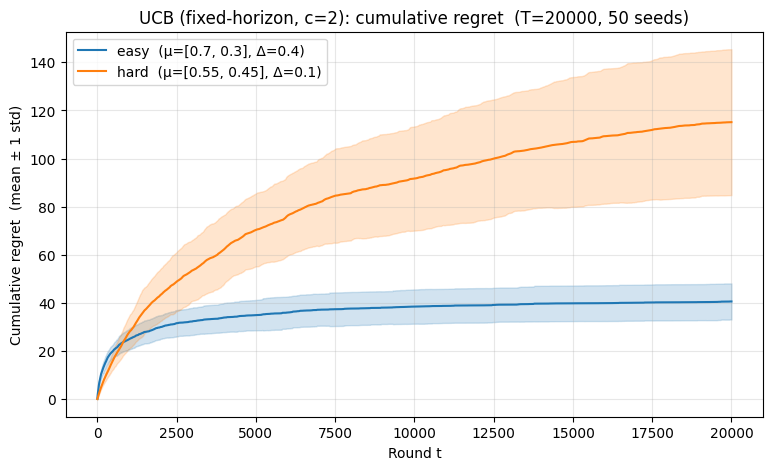

instance          avg pulls arm 0 (best)   avg pulls arm 1 (worse)
easy (Δ=0.4)                       19898                       102
hard (Δ=0.1)                       18849                      1151


In [6]:
# === Task 1, Part A: regret on an easy vs a hard instance ===

T = 20000
n_seeds = 50

def env_factory_easy(rng):
    """2-arm Bernoulli, gap Δ = 0.4."""
    return BernoulliBandit([0.7, 0.3], rng)

def env_factory_hard(rng):
    """2-arm Bernoulli, gap Δ = 0.1."""
    return BernoulliBandit([0.55, 0.45], rng)

# ucb is called with default arguments: fixed-horizon, c=2, sigma=1.
easy_regret, easy_arms = run_experiment(ucb, env_factory_easy, T, n_seeds)
hard_regret, hard_arms = run_experiment(ucb, env_factory_hard, T, n_seeds)

fig, ax = plt.subplots(figsize=(9, 5))
plot_averaged_regret(easy_regret, "easy  (μ=[0.7, 0.3], Δ=0.4)", ax)
plot_averaged_regret(hard_regret, "hard  (μ=[0.55, 0.45], Δ=0.1)", ax)
ax.set_title(f"UCB (fixed-horizon, c=2): cumulative regret  (T={T}, {n_seeds} seeds)")
plt.show()

# Average pull counts per arm (arm 0 is the best arm in both instances).
# run_experiment returns the per-round arm choices; count how many times each arm was pulled.
easy_pull_counts = np.array([(easy_arms == k).sum(axis=1) for k in range(2)]).mean(axis=1)
hard_pull_counts = np.array([(hard_arms == k).sum(axis=1) for k in range(2)]).mean(axis=1)
print(f"{'instance':<16}{'avg pulls arm 0 (best)':>24}{'avg pulls arm 1 (worse)':>26}")
print(f"{'easy (Δ=0.4)':<16}{easy_pull_counts[0]:>24.0f}{easy_pull_counts[1]:>26.0f}")
print(f"{'hard (Δ=0.1)':<16}{hard_pull_counts[0]:>24.0f}{hard_pull_counts[1]:>26.0f}")


**Write-up prompt — 1 mark.**

The easy curve flattens to a low value, while the hard curve keeps climbing through $T = 20000$. Lecture 4 showed that for UCB, $T_i(T) \le 8 \log T / \Delta_i^2 + 1$, where $\Delta_i = \mu^\star - \mu_i$ is the gap. The piece of this bound that matters here is the $1/\Delta^2$ scaling. Use it to explain the late-time behaviour of the two curves, and check it against the printed pull counts. Also explain one early-time observation: why is the easy instance's cumulative regret *higher* than the hard one during the first few rounds?


**Observations.**

The two instances differ only in the gap $\Delta$, and almost everything follows from this.

*Late behaviour.* The Lecture 4 bound $T_i(T) \le 8 \log T / \Delta_i^2 + 1$ is an upper bound on the expected number of suboptimal-arm pulls. The piece that drives the contrast between the two instances is the $1/\Delta^2$ scaling. Shrinking the gap by a factor of $4$ (from $0.4$ to $0.1$) raises the upper bound by a factor of $16$. The printed table shows about $100$ pulls in the easy case and about $1150$ in the hard case, a ratio of roughly $11$. The bound itself, evaluated at $T = 20000$ and $c = 2$, gives roughly $500$ for the easy case and $8000$ for the hard case — both well above the observed counts, which is fine because the bound is an upper bound. The $1/\Delta^2$ growth rate is what we set out to check, and the observed ratio between the two instances is in the same range as the predicted factor of $16$. Each suboptimal pull contributes $\Delta$ to the regret, so the easy instance flattens quickly while the hard instance keeps climbing through $T = 20000$.

*Early behaviour.* In the first few rounds, both algorithms have pulled each arm only once or twice, so the number of mistakes is similar in the two instances. A mistake costs $\Delta$, and $\Delta = 0.4$ in the easy case versus $0.1$ in the hard case. So the easy instance accumulates regret faster at the start. The crossover happens once the hard instance has made enough extra mistakes for its larger count to overtake the easy instance's larger per-mistake cost.


**Seeing UCB at work.** One seed per instance, shorter horizon so that the early dynamics are visible. For each arm we plot the index $UCB_i(t)$ (solid — this is what the algorithm uses to pick an arm), the confidence interval (shaded), the empirical mean (dashed), and the true mean (dotted). The two panels show the easy and hard instances side by side.

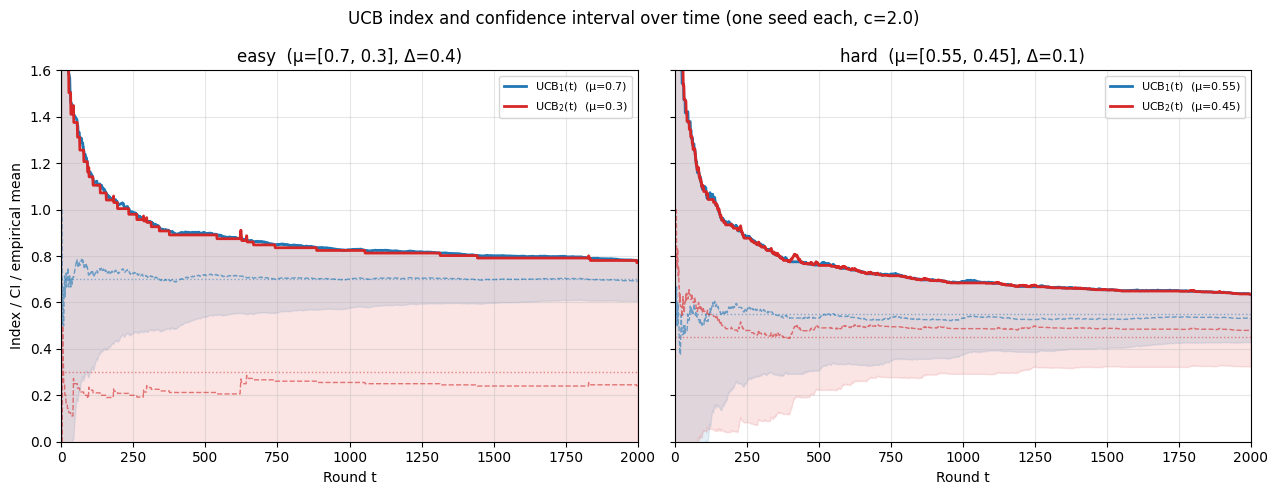

In [7]:
# === Task 1, Part A: seeing UCB at work — easy vs hard, side by side ===

T_band = 2000
c = 2.0

def ucb_deepdive_panel(ax, env_factory, title):
    rng = np.random.default_rng(BASE_SEED)
    env = env_factory(rng)
    _, _, trace = ucb(env, T_band, c=c, return_trace=True)

    means_hat = trace["means_hat"]
    counts = trace["counts"]
    t_axis = np.arange(1, T_band + 1)

    # Fixed-horizon bonus: U_i(t) = sqrt(c * log(T_band) / N_i(t)).
    with np.errstate(divide="ignore", invalid="ignore"):
        U = np.sqrt(c * np.log(T_band) / counts)
    valid = counts > 0
    mu = np.where(valid, means_hat, np.nan)
    upper = np.where(valid, means_hat + U, np.nan)
    lower = np.where(valid, means_hat - U, np.nan)

    colors = ["#1f77b4", "#d62728"]
    for i in range(env.K):
        ax.fill_between(t_axis, lower[:, i], upper[:, i], color=colors[i], alpha=0.12)
        ax.plot(t_axis, upper[:, i], color=colors[i], lw=2.0,
                label=f"UCB$_{i+1}$(t)  (μ={env.means[i]})")
        ax.plot(t_axis, mu[:, i], color=colors[i], lw=1.0, alpha=0.6, ls="--")
        ax.axhline(env.means[i], color=colors[i], ls=":", lw=1, alpha=0.5)
    ax.set_ylim(0.0, 1.6); ax.set_xlim(0, T_band)
    ax.set_xlabel("Round t"); ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ucb_deepdive_panel(axes[0], env_factory_easy, "easy  (μ=[0.7, 0.3], Δ=0.4)")
ucb_deepdive_panel(axes[1], env_factory_hard, "hard  (μ=[0.55, 0.45], Δ=0.1)")
axes[0].set_ylabel("Index / CI / empirical mean")
fig.suptitle(f"UCB index and confidence interval over time (one seed each, c={c})")
plt.tight_layout()
fig.subplots_adjust(left=0.06)
plt.show()


**Write-up prompt — 1 mark.**

In both panels, the two solid index curves stay close together near the top and keep swapping the lead — even on the easy instance, where the worse arm is pulled only a few times. When you pull an arm, its bonus shrinks for certain, while its empirical mean only fluctuates up or down. Use this to explain why being on top is *self-correcting* (your explanation should account for the occasional upward jumps in the solid curves). Then, in terms of pull counts, explain why the worse arm keeps getting pulled almost forever in the hard case but only rarely in the easy case.


**Observations.**

When we pull an arm, two things happen to its index $UCB_i = \hat\mu_i + U_i$. The bonus $U_i = \sqrt{c\log T / T_i}$ shrinks for certain, because $T_i$ increases and never decreases. The empirical mean $\hat\mu_i$ only fluctuates: a single reward pushes it up or down, and on average it drifts toward the true mean $\mu_i$. So the bonus is the part of the index that is guaranteed to move, and it always moves downward.

This makes being on top self-correcting. At each round, the arm with the largest index is pulled, which means the pull is spent on the current leader and its bonus shrinks. As soon as the leader's index drops below another arm's, the lead passes to that arm, and the algorithm begins shrinking the new leader's bonus instead. No arm can stay above the others for long: being chosen is what pulls it back down. The occasional upward jumps in the solid curves come from lucky rewards that raise $\hat\mu_i$ for a moment. These jumps are temporary, because the next few pulls average them out, while the bonus reduction is permanent.

The difference between the easy and hard instances is only how often this swapping happens. In the easy case the gap is large, so after about a hundred pulls the worse arm's empirical mean has fallen below the better arm's, and even a full bonus cannot lift its index back into the lead. The swapping stops and the worse arm is abandoned. In the hard case the gap is small, so the worse arm's inflated index keeps coming back level with the leader. The swapping continues throughout the horizon, and the worse arm keeps being pulled.


### Part B — tuning the confidence width *(2 marks)*

The constant $c$ controls how wide the confidence interval is, and therefore how strongly the bonus $\sqrt{c\log T / T_i}$ inflates each arm's index. It is a hyper-parameter of the UCB algorithm. If $c$ is too small, the algorithm explores very little. If $c$ is too large, it explores too much.

In this part you sweep $c$ over a wide range on the **hard** 3-arm instance $\mu = (0.55, 0.50, 0.45)$, the same instance used in Lecture 4. The four values are $c \in \{0.05, 0.25, 2, 20\}$, with the labels from Lecture 4: $c = 0.05$ too small, $c = 0.25$ just right, $c = 2$ the textbook (theoretically safe) value, and $c = 20$ too large.

**Plot 1.** Cumulative regret, averaged over many seeds, for each value of $c$.

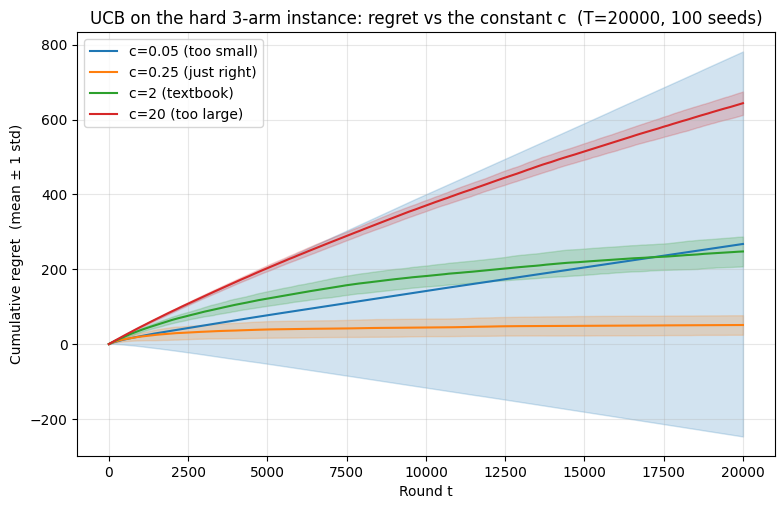

In [8]:
# === Task 1, Part B: cumulative regret across a sweep of c ===

T = 20000
n_seeds = 100   # reduce (e.g. to 30) if this is slow on your machine

def env_factory_hard3(rng):
    """3-arm Bernoulli hard instance from Lecture 4."""
    return BernoulliBandit([0.55, 0.50, 0.45], rng)

c_values = [0.05, 0.25, 2.0, 20.0]
c_labels = {0.05: "c=0.05 (too small)", 0.25: "c=0.25 (just right)",
            2.0:  "c=2 (textbook)",     20.0: "c=20 (too large)"}

# Per-seed cumulative regret for each c; reused by Plot 2.
cumreg_by_c = {}

fig, ax = plt.subplots(figsize=(9, 5.5))
for c in c_values:
    algo = partial(ucb, c=c)
    inst_regret, _ = run_experiment(algo, env_factory_hard3, T, n_seeds)
    cumreg_by_c[c] = inst_regret.cumsum(axis=1)               # (n_seeds, T)
    plot_averaged_regret(inst_regret, c_labels[c], ax)
ax.set_title(f"UCB on the hard 3-arm instance: regret vs the constant c  (T={T}, {n_seeds} seeds)")
plt.show()


**Write-up prompt — 1 mark.**

Describe what goes wrong at each extreme: very small $c$ and very large $c$. Why is the theoretically "safe" textbook value $c = 2$ beaten here by the smaller $c = 0.25$? (Connect to Lecture 4: the Hoeffding-based confidence interval is an *upper bound* on the deviation, so the constant it suggests is conservative.)

**Observations.**

The two extremes fail in opposite ways. When $c$ is too small ($c = 0.05$), the bonus is too weak. The algorithm trusts its early empirical means too much and stops exploring before it has reliably identified the best arm. On most seeds this is harmless, but on some seeds it commits to a wrong arm and keeps paying for it, which is why the $c = 0.05$ curve has such a wide band. When $c$ is too large ($c = 20$), the bonus is so strong that the algorithm keeps exploring all arms long after the best one has been identified, and the regret grows steadily on every seed.

The textbook value $c = 2$ is "safe" in the sense that the Lecture 4 regret proof goes through for it. But that proof is built on Hoeffding's inequality, which gives an upper bound on how far the empirical mean can stray from the truth. A bound that must hold in the worst case is loose for typical runs, so the value of $c$ guaranteed by the theory is larger than the value that performs best on a given instance. On this instance the smaller $c = 0.25$ explores just enough and beats $c = 2$. The theoretically safe constant is conservative, and problem-specific tuning pays off in practice.


**Plot 2 — what the average curve hides.** A mean regret curve hides how different seeds behave. We now look at the *final cumulative regret* of each individual seed, one strip per value of $c$. Pay particular attention to the smallest value of $c$, and compare where most of its points sit against where its mean (red marker) sits.

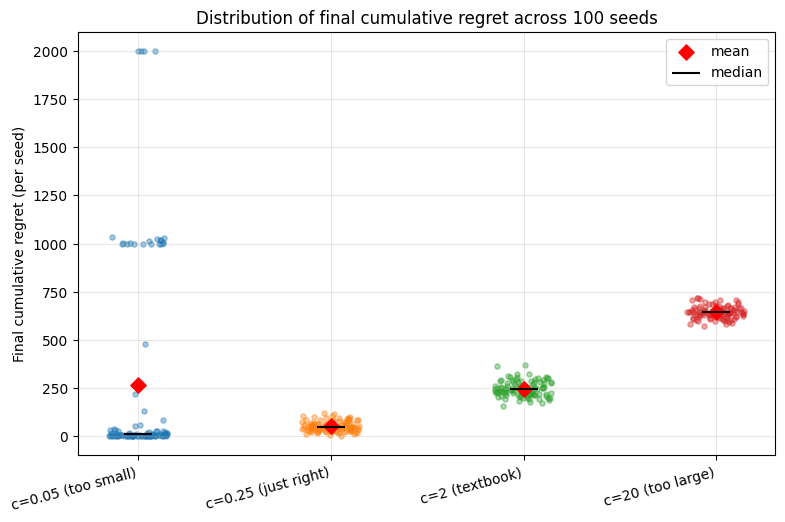

In [9]:
# === Task 1, Part B: distribution of final cumulative regret across seeds ===

fig, ax = plt.subplots(figsize=(9, 5.5))
positions = np.arange(len(c_values))
for j, c in enumerate(c_values):
    pts = cumreg_by_c[c][:, -1]                # final cumulative regret per seed
    jitter = (np.random.default_rng(j).random(len(pts)) - 0.5) * 0.3
    ax.scatter(np.full_like(pts, positions[j], dtype=float) + jitter, pts, s=14, alpha=0.4)
    ax.scatter([positions[j]], [pts.mean()], color="red", marker="D", s=60, zorder=5,
               label="mean" if j == 0 else None)
    ax.scatter([positions[j]], [np.median(pts)], color="black", marker="_", s=400, zorder=5,
               label="median" if j == 0 else None)
ax.set_xticks(positions)
ax.set_xticklabels([c_labels[c] for c in c_values], rotation=15, ha="right")
ax.set_ylabel("Final cumulative regret (per seed)")
ax.set_title(f"Distribution of final cumulative regret across {n_seeds} seeds")
ax.legend()
plt.show()


**Plot 3 — looking inside a failure run.** To see what goes wrong in a high-regret run, we plot the UCB indices of all three arms on a single seed, for two values of $c$: $c = 0.25$ (just right) and $c = 0.05$ (too small). Compare the three index curves across the two panels.

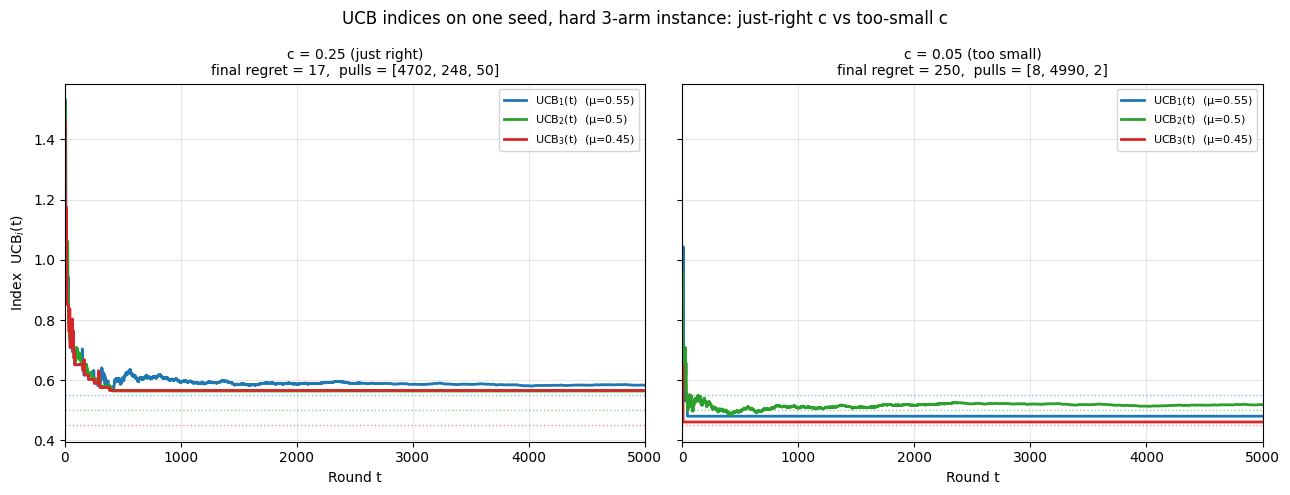

In [10]:
# === Task 1, Part B: what under-exploration looks like (one seed) ===

T_band = 5000
seed = BASE_SEED + 7                           # a seed where c=0.05 commits to a wrong arm

def ucb_index_panel(ax, c, title):
    rng = np.random.default_rng(seed)
    env = env_factory_hard3(rng)
    arms_run, regrets_run, trace = ucb(env, T_band, c=c, return_trace=True)
    means_hat = trace["means_hat"]; counts = trace["counts"]
    t_axis = np.arange(1, T_band + 1)
    with np.errstate(divide="ignore", invalid="ignore"):
        U = np.sqrt(c * np.log(T_band) / counts)
    valid = counts > 0
    upper = np.where(valid, means_hat + U, np.nan)
    colors = ["#1f77b4", "#2ca02c", "#d62728"]
    for i in range(env.K):
        ax.plot(t_axis, upper[:, i], color=colors[i], lw=2.0,
                label=f"UCB$_{i+1}$(t)  (μ={env.means[i]})")
        ax.axhline(env.means[i], color=colors[i], ls=":", lw=1, alpha=0.5)
    ax.set_xlim(0, T_band); ax.set_xlabel("Round t")

    # Append final cumulative regret and per-arm pulls to the title.
    final_reg = regrets_run.sum()
    pulls = [int((arms_run == i).sum()) for i in range(env.K)]
    detail = f"final regret = {final_reg:.0f},  pulls = {pulls}"
    ax.set_title(f"{title}\n{detail}", fontsize=10)
    ax.legend(loc="upper right", fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ucb_index_panel(axes[0], 0.25, "c = 0.25 (just right)")
ucb_index_panel(axes[1], 0.05, "c = 0.05 (too small)")
axes[0].set_ylabel("Index  UCB$_i$(t)")
fig.suptitle(f"UCB indices on one seed, hard 3-arm instance: just-right c vs too-small c")
plt.tight_layout()
plt.show()


**Write-up prompt — 1 mark.**

For the smallest $c$, the mean (Plot 2) sits far above the median. What does this say about the shape of the regret distribution, and what kind of run produces the high-regret outliers? Plot 3 shows one such run beside a healthy one: explain why a small $c$ breaks the self-correcting behaviour you described in Part A. (Hint: what happens to a small bonus once an arm has been pulled a moderate number of times?)

**Observations.**

For $c = 0.05$, the strip plot shows most seeds sitting close to zero (low median), but a handful of seeds sit high, some near $1000$ and a few close to $2000$. The mean is pulled up by these few large values and sits far above the median. A mean much greater than the median is the signature of a skewed distribution with a long tail on the high side. The typical run does very well, but the average is dominated by these rare failures.

The high-regret runs are the ones where the algorithm committed to a wrong arm. Plot 3 shows one such run beside a healthy one. With $c = 0.25$ (just right), all three index curves stay close together and keep swapping the lead, just as in Part A, so the self-correcting behaviour is intact. With $c = 0.05$ (too small), the arm with $\mu = 0.5$ (not the best) gets an early lucky lead, and the bonus is now too small to lift the other arms' indices back above it. The true best arm ($\mu = 0.55$) stays stuck below and is hardly pulled again. A small bonus breaks the self-correction: once an arm has been pulled a moderate number of times, $\sqrt{c\log T / T_i}$ with a tiny $c$ is too small to overcome even a small deficit in the empirical mean, so a wrong early leader is never displaced.


### Part C — the anytime version of UCB *(1 mark)*

The fixed-horizon UCB index uses $\log T$ inside the bonus, which requires knowing the total number of rounds $T$ in advance. The **anytime** version replaces $\log T$ with $\log t$, where $t$ is the current round number. In the `ucb` function, this is `mode="anytime"`.

The plot below compares the two versions on the hard 3-arm instance from Part B. Both are run over the same actual horizon $T = 20000$ with $c = 2$; the fixed-horizon version is additionally told the correct value of $T$, while the anytime version does not use $T$ at all.

**Plot — anytime vs fixed-horizon.**

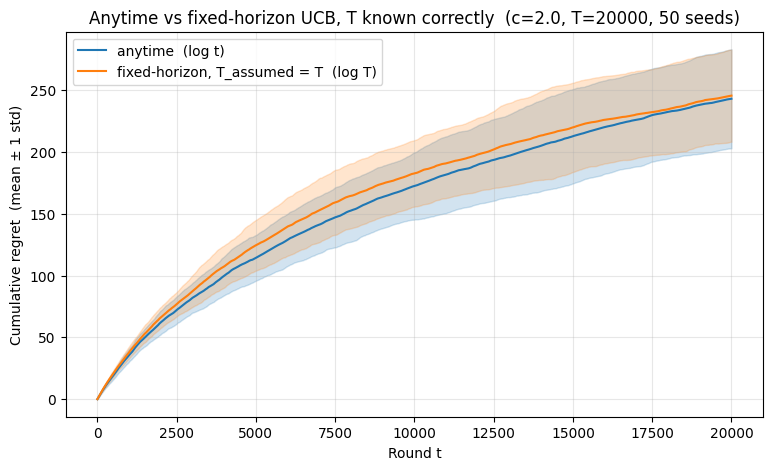

In [11]:
# === Task 1, Part C: anytime vs fixed-horizon, T known correctly ===

T = 20000
n_seeds = 50
c = 2.0

anytime_regret, _ = run_experiment(
    partial(ucb, c=c, mode="anytime"), env_factory_hard3, T, n_seeds)
fixed_regret, _ = run_experiment(
    partial(ucb, c=c, mode="fixed_horizon"), env_factory_hard3, T, n_seeds)

fig, ax = plt.subplots(figsize=(9, 5))
plot_averaged_regret(anytime_regret, "anytime  (log t)", ax)
plot_averaged_regret(fixed_regret, "fixed-horizon, T_assumed = T  (log T)", ax)
ax.set_title(f"Anytime vs fixed-horizon UCB, T known correctly  (c={c}, T={T}, {n_seeds} seeds)")
plt.show()


**Write-up prompt — 1 mark.**

The two curves are nearly identical — why? (Compare $\log t$ and $\log T$ over the range $K \le t \le T$, and remember that the bonus uses the *square root* of this term.) Next, notice that $c$ and $T_{\text{assumed}}$ enter the bonus only through the product $c \cdot \log T_{\text{assumed}}$, so changing one is equivalent to changing the other. In what sense is there only *one* hyper-parameter and not two, and what does the anytime version eliminate from this list (while leaving what still to tune)?

**Observations.**

The two curves are nearly identical because $\log t$ and $\log T$ are very close for the values of $t$ that matter. Once the initial few rounds are over, $t$ ranges from a small number up to $T = 20000$. Even at $t = 200$, $\log t \approx 5.3$ against $\log T \approx 9.9$, and the bonus uses the *square root* of this quantity, so the ratio of the two bonuses is at most $\sqrt{9.9 / 5.3} \approx 1.37$, and for most of the horizon it is much closer to $1$. A difference of this size in the bonus has almost no effect on which arm has the largest index, so the two algorithms make nearly the same choices and accumulate nearly the same regret.

On the second point: in the bonus $\sigma\sqrt{c\,\log(\text{time\_factor})/T_i}$, the constant $c$ and the assumed horizon enter only through the product $c \cdot \log T_{\text{assumed}}$. Doubling $c$ has the same effect on the bonus as squaring $T_{\text{assumed}}$. So there is really only one quantity to set, the overall size of the exploration bonus, and $c$ and $T_{\text{assumed}}$ are two ways of writing the same knob, not two independent ones. The anytime version removes one piece of this: by replacing the fixed $\log T$ with $\log t$, which grows on its own as the experiment proceeds, we no longer have to commit to a horizon $T_{\text{assumed}}$ in advance. The constant $c$ remains a tuning knob: it still controls the overall size of the exploration bonus and still needs a sensible default.


### Part D — UCB for Gaussian rewards *(1 mark)*

So far the rewards have been Bernoulli (0 or 1). We now consider **Gaussian rewards**. Each arm produces a noisy reward $X_t = \mu_i + \epsilon_t$, where $\epsilon_t \sim \mathcal{N}(0, \sigma^2)$. The noise standard deviation $\sigma$ is the same for all arms and is known to the algorithm.

The UCB index extends naturally:

$$ UCB_i(t) \;=\; \hat\mu_i(t) \;+\; \sigma \sqrt{\dfrac{c \, \log T}{T_i(t)}}. $$

The bonus now scales with $\sigma$: the confidence interval around an empirical mean is wider when the noise is larger. (For Bernoulli rewards the confidence width came from Hoeffding's inequality for bounded rewards; for Gaussian rewards it comes from the same sub-Gaussian idea, now with the known scale $\sigma$ in place of the bound.) The cell below defines a `GaussianBandit` environment, on the same lines as `BernoulliBandit`. You do not need to edit it.

In [12]:
# === Provided: GaussianBandit environment ===

class GaussianBandit:
    """K-arm bandit with Gaussian rewards.

    Each arm i has true mean means[i]. When arm i is pulled, the reward is
    drawn from N(means[i], sigma^2). The noise standard deviation sigma is
    the same for all arms.
    """
    def __init__(self, means, sigma, rng):
        self.means = np.asarray(means, dtype=float)
        self.sigma = float(sigma)
        self.K = len(self.means)
        self.rng = rng
        self.best_mean = float(self.means.max())
        self.best_arm = int(np.argmax(self.means))
        self.pull_counts = np.zeros(self.K, dtype=int)

    def pull(self, a):
        self.pull_counts[a] += 1
        return float(self.rng.normal(self.means[a], self.sigma))

    def instantaneous_regret(self, a):
        return self.best_mean - self.means[a]


**Plot — low vs high noise.** Same arm means as in Part B, $\mu = (0.55, 0.50, 0.45)$, compared at two noise levels: $\sigma = 0.3$ (low) and $\sigma = 1.0$ (high). In each case we tell the algorithm the correct $\sigma$ via the `sigma` argument.

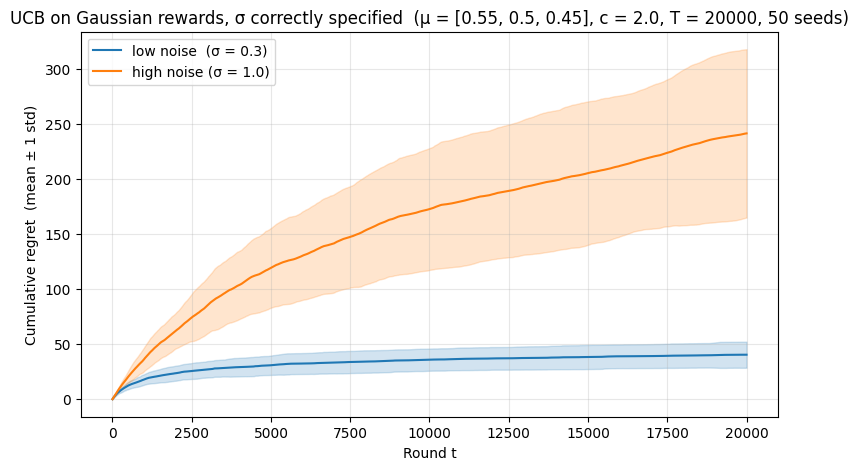

In [13]:
# === Task 1, Part D: UCB on Gaussian rewards, low vs high noise ===

T = 20000
n_seeds = 50
c = 2.0
gaussian_means = [0.55, 0.50, 0.45]

def env_gauss_low(rng):
    return GaussianBandit(gaussian_means, sigma=0.3, rng=rng)

def env_gauss_high(rng):
    return GaussianBandit(gaussian_means, sigma=1.0, rng=rng)

# Tell UCB the correct sigma in each case.
low_regret, _  = run_experiment(partial(ucb, c=c, sigma=0.3), env_gauss_low,  T, n_seeds)
high_regret, _ = run_experiment(partial(ucb, c=c, sigma=1.0), env_gauss_high, T, n_seeds)

fig, ax = plt.subplots(figsize=(9, 5))
plot_averaged_regret(low_regret,  "low noise  (σ = 0.3)",  ax)
plot_averaged_regret(high_regret, "high noise (σ = 1.0)", ax)
ax.set_title(f"UCB on Gaussian rewards, σ correctly specified  (μ = {gaussian_means}, c = {c}, T = {T}, {n_seeds} seeds)")
plt.show()


**Write-up prompt — 1 mark.**

Why must the bonus scale with $\sigma$? (Think about how the width of a confidence interval for the mean of $T_i$ Gaussian samples depends on $\sigma$.) And why does the high-noise case produce higher cumulative regret, even though the arm means are identical in the two cases?

**Observations.**

The bonus is the half-width of the confidence interval around the empirical mean, and that width is set by how noisy the rewards are. For the average of $T_i$ independent samples from a distribution with standard deviation $\sigma$, the standard error of the mean is $\sigma / \sqrt{T_i}$. The confidence interval therefore scales directly with $\sigma$: noisier rewards mean a wider interval for the same number of pulls. This is the $\sigma$ factor in $\sigma\sqrt{c\log T / T_i}$. If we dropped it, a high-noise arm would get a confidence interval that is too narrow, and the algorithm would become over-confident about its empirical mean.

The high-noise case gives higher cumulative regret even though the arm means are identical, because the gap of $0.05$ between the arms is now buried under much larger fluctuations. With $\sigma = 1.0$, a single reward swings far more than $0.05$, so the empirical means of two arms are dominated by noise for a long time, and many pulls are needed before the ordering of the arms becomes clear. With $\sigma = 0.3$ the same gap stands out from the noise much sooner, the best arm is identified quickly, and the regret stays low. What matters is the gap *relative* to the noise; a larger $\sigma$ makes the same gap harder to detect.


### Part E — when the variance is unknown *(not graded)*

In Part D we told UCB the true $\sigma$. In practice $\sigma$ is unknown — it must be estimated from data or simply guessed. What happens if the guess is wrong? Since the bonus scales linearly with the $\sigma$ we plug in, guessing $\sigma$ too small shrinks every bonus, and guessing too large inflates it.

We fix a Gaussian bandit with true $\sigma = 1.0$ on the hard 3-arm instance, and run UCB with three guessed values: $\sigma = 0.3$ (too small), $\sigma = 1.0$ (correct), $\sigma = 3.0$ (too large).

**Plot 1 — guessing $\sigma$ wrong.** Averaged cumulative regret for the three guesses.

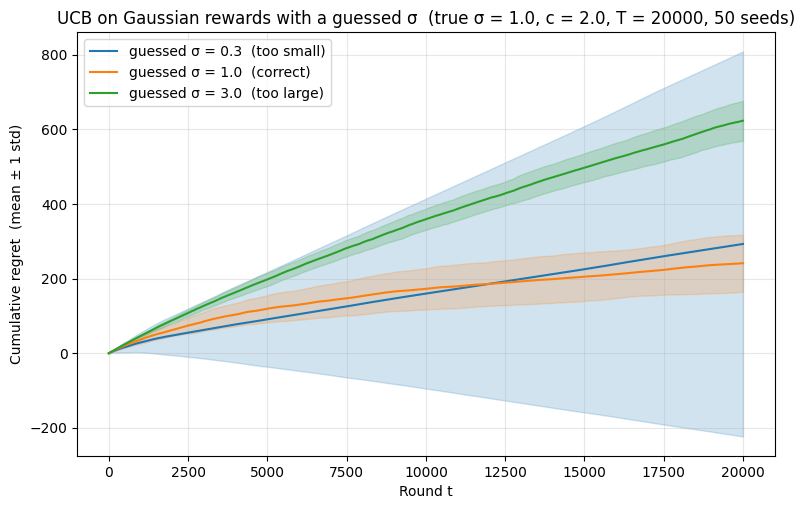

In [14]:
# === Task 1, Part E (not graded): UCB on Gaussian rewards with a guessed sigma ===

T = 20000
n_seeds = 50
c = 2.0
gaussian_means = [0.55, 0.50, 0.45]
true_sigma = 1.0

def env_gauss_true(rng):
    return GaussianBandit(gaussian_means, sigma=true_sigma, rng=rng)

sigma_guesses = [0.3, 1.0, 3.0]            # too small, correct, too large
cumreg_by_sigma = {}

fig, ax = plt.subplots(figsize=(9, 5.5))
for su in sigma_guesses:
    inst_regret, _ = run_experiment(partial(ucb, c=c, sigma=su), env_gauss_true, T, n_seeds)
    cumreg_by_sigma[su] = inst_regret.cumsum(axis=1)
    note = "too small" if su < true_sigma else ("correct" if su == true_sigma else "too large")
    plot_averaged_regret(inst_regret, f"guessed σ = {su}  ({note})", ax)
ax.set_title(f"UCB on Gaussian rewards with a guessed σ  (true σ = {true_sigma}, c = {c}, T = {T}, {n_seeds} seeds)")
plt.show()


**Plot 2 — the spread behind the average.** Final cumulative regret of each seed, one strip per guessed $\sigma$. Look at the too-small guess.

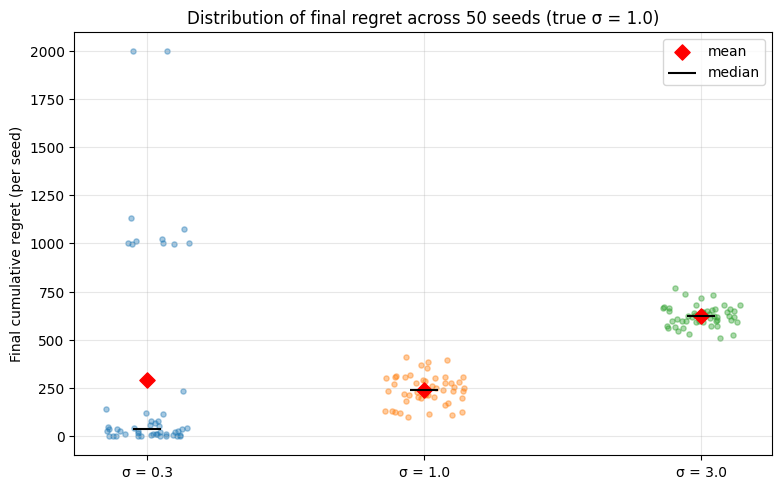

In [15]:
# === Task 1, Part E (not graded): spread across seeds ===

fig, ax = plt.subplots(figsize=(9, 5.5))
positions = np.arange(len(sigma_guesses))
for j, su in enumerate(sigma_guesses):
    pts = cumreg_by_sigma[su][:, -1]
    jitter = (np.random.default_rng(j).random(len(pts)) - 0.5) * 0.3
    ax.scatter(np.full_like(pts, positions[j], dtype=float) + jitter, pts, s=14, alpha=0.4)
    ax.scatter([positions[j]], [pts.mean()], color="red", marker="D", s=60, zorder=5,
               label="mean" if j == 0 else None)
    ax.scatter([positions[j]], [np.median(pts)], color="black", marker="_", s=400, zorder=5,
               label="median" if j == 0 else None)
ax.set_xticks(positions)
ax.set_xticklabels([f"σ = {su}" for su in sigma_guesses])
ax.set_ylabel("Final cumulative regret (per seed)")
ax.set_title(f"Distribution of final regret across {n_seeds} seeds (true σ = {true_sigma})")
ax.legend()
plt.show()


**Write-up prompt (not graded).** Answer if you wish.

1. Relate the three regret curves to the $c$-sweep in Part B. Why does a guessed $\sigma$ that is too small behave like a $c$ that is too small?
2. For the too-small guess, the mean sits far above the median, and the points split into a low group and a high group. What kind of run lands in each group, and why is this a real danger when you do not know $\sigma$ in advance?

**Observations.**

1. The $\sigma$ we plug into the bonus multiplies the whole bonus term, exactly as $\sqrt{c}$ does. So plugging in a $\sigma$ that is too small shrinks every bonus, which is the same effect as $c$ being too small: the algorithm under-explores. This is why the "guessed $\sigma$ too small" curve behaves like the "$c$ too small" curve from Part B, the correct $\sigma$ behaves like a reasonable $c$, and an over-large $\sigma$ behaves like an over-large $c$ (steady over-exploration). Under-estimating the noise and under-estimating $c$ are the same mistake.

2. For the too-small guess ($\sigma = 0.3$ when the truth is $1.0$), the strip plot splits into a low group near zero and a high group up to about $2000$, with the mean sitting well above the median. The low group are the runs where the algorithm happened to settle on the best arm; the high group are the runs where it committed early to a wrong arm and never recovered, because the shrunken bonus could not bring the other arms back into contention. This is a real danger in practice: when $\sigma$ is unknown, a confident under-estimate will look excellent on most runs and on the average of a few runs you might report, while occasionally producing a rare high-regret run. When in doubt it is safer to over-estimate $\sigma$ (or $c$): you pay a steady, predictable price in exploration rather than risking these rare failures.
